# Quantization

In [ ]:
!pip install onnx onnxruntime onnx-simplifier segmentation-models-pytorch

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp
import onnx
from onnxsim import simplify
from onnxruntime.quantization import quantize_dynamic, QuantType

# ================= CONFIG =================
# Đường dẫn file model ResNet101 của bạn
CHECKPOINT_PATH = r"E:\FPT\DAP391m\model\best_model_resnet101.pth"
DEVICE = "cpu"

# ================= MODEL ARCHITECTURE =================
class ASPP(nn.Module):
    def __init__(self, in_dims, out_dims):
        super().__init__()
        self.conv1 = nn.Conv2d(in_dims, out_dims, 1, bias=False)
        self.conv2 = nn.Conv2d(in_dims, out_dims, 3, padding=6, dilation=6, bias=False)
        self.conv3 = nn.Conv2d(in_dims, out_dims, 3, padding=12, dilation=12, bias=False)
        self.conv_pool = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(in_dims, out_dims, 1, bias=False))
        self.fuse = nn.Sequential(nn.Conv2d(out_dims*4, out_dims, 1), nn.BatchNorm2d(out_dims), nn.ReLU())

    def forward(self, x):
        h, w = x.shape[-2:]
        res = [
            self.conv1(x),
            self.conv2(x),
            self.conv3(x),
            torch.nn.functional.interpolate(self.conv_pool(x), size=(h,w), mode='bilinear', align_corners=True)
        ]
        return self.fuse(torch.cat(res, dim=1))

class FlexibleFloodModel(nn.Module):
    def __init__(self, encoder_name='resnet101'):
        super().__init__()
        self.base = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=None,
            in_channels=8,
            classes=1,
            decoder_attention_type='scse' 
        )
        ch = self.base.encoder.out_channels[-1]
        self.aspp = ASPP(ch, ch)

    def forward(self, x):
        feats = self.base.encoder(x)
        feats[-1] = self.aspp(feats[-1])
        dec = self.base.decoder(feats)
        return self.base.segmentation_head(dec)

# ================= PIPELINE FUNCTION =================
def run_quantization_pipeline():
    # Định nghĩa các tên file bên trong hàm để tránh lỗi scope
    fp32_path = "flood_temp_fp32.onnx"
    simp_path = "flood_temp_simp.onnx"
    final_web_model = "flood_resnet101_web_int8.onnx"

    print("🚀 Bắt đầu Pipeline chuyển đổi model cho Web...")

    # 1. Load Model
    model = FlexibleFloodModel(encoder_name='resnet101').to(DEVICE)
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    model.eval()

    # 2. Export sang ONNX
    print("🔄 Bước 1: Export sang định dạng ONNX...")
    dummy_input = torch.randn(1, 8, 256, 256).to(DEVICE)
    
    torch.onnx.export(
        model, 
        dummy_input, 
        fp32_path,
        export_params=True,
        opset_version=12,
        do_constant_folding=True,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={'input': {2: 'height', 3: 'width'}, 
                      'output': {2: 'height', 3: 'width'}},
        # Quan trọng: tắt dynamo để tránh lỗi ModuleNotFoundError: onnxscript
        # Nếu phiên bản torch cũ không có tham số dynamo, bạn có thể xóa dòng dưới
        # dynamo=False 
    )

    # 3. Simplify
    print("⚡ Bước 2: Tối ưu hóa cấu trúc (Simplifying)...")
    onnx_model = onnx.load(fp32_path)
    model_simp, check = simplify(onnx_model)
    
    current_source_for_quant = fp32_path
    if check:
        onnx.save(model_simp, simp_path)
        current_source_for_quant = simp_path
        print("✅ Đã simplify thành công.")
    else:
        print("⚠️ Simplify thất bại, sử dụng bản gốc để nén.")

    # 4. Quantization
    print("💎 Bước 3: Nén mô hình xuống INT8 (Quantization)...")
    quantize_dynamic(
        current_source_for_quant, 
        final_web_model,
        weight_type=QuantType.QUInt8
    )

    # 5. Thông số cuối
    size_old = os.path.getsize(CHECKPOINT_PATH) / (1024*1024)
    size_new = os.path.getsize(final_web_model) / (1024*1024)
    
    print("\n" + "="*40)
    print("🎉 HOÀN THÀNH!")
    print(f"🔹 File gốc: {size_old:.2f} MB")
    print(f"🔹 File Web (INT8): {size_new:.2f} MB")
    print(f"📍 File sẵn sàng: {final_web_model}")
    print("="*40)

    # Dọn dẹp
    for f in [fp32_path, simp_path]:
        if os.path.exists(f): os.remove(f)

if __name__ == "__main__":
    run_quantization_pipeline()

# Inference onnx

d:\Application\Anaconda\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


🚀 ONNX FILE: Sample_2025-12-13.npz
📊 NSE: 0.4329 | MSE: 0.021276 | MAE: 0.1219


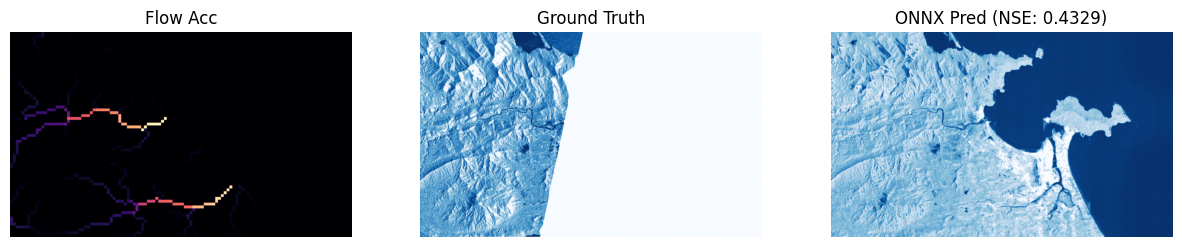

📊 Bắt đầu Batch Evaluation với ONNX (85 files)...


100%|██████████| 85/85 [08:17<00:00,  5.85s/it]


✅ KẾT QUẢ TRUNG BÌNH ONNX:
NSE     0.545125
MSE     0.025159
MAE     0.126539
RMSE    0.155037
KGE     0.720829
R2      0.545125
dtype: float64

🏆 TOP 5 FILES CÓ MSE THẤP NHẤT (CHÍNH XÁC NHẤT):
                     file       MSE       NSE       MAE
73  Sample_2025-04-29.npz  0.008496  0.630559  0.068948
35  Sample_2022-03-10.npz  0.009233  0.617508  0.071419
23  Sample_2021-05-02.npz  0.009300  0.680035  0.076142
20  Sample_2021-03-03.npz  0.009493  0.666612  0.075458
17  Sample_2021-01-26.npz  0.009682  0.591769  0.072052


In [1]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import random
import onnxruntime as ort
from tqdm import tqdm
from sklearn.metrics import r2_score, mean_squared_error # Thêm mean_squared_error
from skimage.restoration import denoise_nl_means, estimate_sigma

# ================= CONFIG =================
MODEL_ONNX_PATH = "flood_resnet101_web_int8.onnx" 
FOLDER_PATH = r"E:\FPT\DAP391m\model\outputres101\test"
PATCH_SIZE = 256
STRIDE = 128
THRESHOLD = 0.15

# Cấu hình Hardware Acceleration
providers = ['CUDAExecutionProvider', 'CPUExecutionProvider'] if ort.get_device() == 'GPU' else ['CPUExecutionProvider']
session = ort.InferenceSession(MODEL_ONNX_PATH, providers=providers)

input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

# ================= UTILS & METRICS (Updated with MSE) =================
def calculate_masked_metrics(y_true, y_pred):
    mask = (y_true > 0.001) & (y_true < 0.999) 
    if not np.any(mask): return 0, 0, 0, 0, 0, 0 # Thêm các giá trị mặc định
    
    y_t, y_p = y_true[mask], y_pred[mask]
    
    mae = np.mean(np.abs(y_t - y_p))
    mse = mean_squared_error(y_t, y_p) # Bổ sung MSE
    rmse = np.sqrt(mse) # Có thể tính thêm RMSE nếu muốn
    
    nse = 1 - (np.sum((y_t - y_p)**2) / (np.sum((y_t - np.mean(y_t))**2) + 1e-10))
    r2 = r2_score(y_t, y_p)
    
    # KGE
    r = np.corrcoef(y_t, y_p)[0, 1] if np.std(y_p) > 0 else 0
    alpha = np.std(y_p) / (np.std(y_t) + 1e-10)
    beta = np.mean(y_p) / (np.mean(y_t) + 1e-10)
    kge = 1 - np.sqrt((r-1)**2 + (alpha-1)**2 + (beta-1)**2)
    
    return mae, mse, rmse, r2, nse, kge

def sota_denoise(y_pred):
    img = y_pred.astype(np.float64)
    sigma_est = np.mean(estimate_sigma(img, channel_axis=None))
    return denoise_nl_means(img, h=0.8 * sigma_est, fast_mode=True, patch_size=5, patch_distance=6)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# ================= 3. ONNX INFERENCE ENGINE (Updated) =================
def smart_inference_onnx(test_files, folder_path, g_min, g_max):
    file_name = random.choice(test_files)
    data = np.load(os.path.join(folder_path, file_name))
    x_full, y_true = data['x'], data['y']
    h, w = y_true.shape

    g_min_tile = g_min.reshape(8, 1, 1)
    g_max_tile = g_max.reshape(8, 1, 1)

    pad_h = (PATCH_SIZE - h % PATCH_SIZE) % PATCH_SIZE
    pad_w = (PATCH_SIZE - w % PATCH_SIZE) % PATCH_SIZE
    x_padded = np.pad(x_full, ((0,0), (0, pad_h), (0, pad_w)), mode='reflect')
    h_p, w_p = x_padded.shape[1:]

    y_pred_sum = np.zeros((h_p, w_p))
    y_count = np.zeros((h_p, w_p))

    for i in range(0, h_p - PATCH_SIZE + 1, STRIDE):
        for j in range(0, w_p - PATCH_SIZE + 1, STRIDE):
            patch = x_padded[:, i:i+PATCH_SIZE, j:j+PATCH_SIZE]
            patch = (patch - g_min_tile) / (g_max_tile - g_min_tile + 1e-7)
            patch = patch[np.newaxis, ...].astype(np.float32)
            
            outputs = session.run([output_name], {input_name: patch})
            pred = sigmoid(outputs[0].squeeze())
            
            y_pred_sum[i:i+PATCH_SIZE, j:j+PATCH_SIZE] += pred
            y_count[i:i+PATCH_SIZE, j:j+PATCH_SIZE] += 1

    y_p = np.divide(y_pred_sum, y_count, out=np.zeros_like(y_pred_sum), where=y_count!=0)[:h, :w]
    y_p = sota_denoise(y_p)
    y_p[y_p < THRESHOLD] = 0
    if y_p.max() > 0:
        y_p = (y_p - y_p.min()) / (y_p.max() - y_p.min() + 1e-7)
    y_p = np.clip(y_p, 0, 1)

    # Metrics
    mae, mse, rmse, r2, nse, kge = calculate_masked_metrics(y_true, y_p)
    print(f"🚀 ONNX FILE: {file_name}")
    print(f"📊 NSE: {nse:.4f} | MSE: {mse:.6f} | MAE: {mae:.4f}")

    plt.figure(figsize=(15, 5))
    plt.subplot(131); plt.imshow(data['x'][7], cmap='magma'); plt.title("Flow Acc"); plt.axis('off')
    plt.subplot(132); plt.imshow(y_true, cmap='Blues'); plt.title("Ground Truth"); plt.axis('off')
    plt.subplot(133); plt.imshow(y_p, cmap='Blues'); plt.title(f"ONNX Pred (NSE: {nse:.4f})"); plt.axis('off')
    plt.show()

# ================= 4. BATCH EVALUATION ONNX (Updated) =================
def batch_evaluate_onnx(test_files, folder_path, g_min, g_max):
    results = []
    g_min_tile = g_min.reshape(8, 1, 1)
    g_max_tile = g_max.reshape(8, 1, 1)
    
    print(f"📊 Bắt đầu Batch Evaluation với ONNX ({len(test_files)} files)...")
    for file_name in tqdm(test_files):
        try:
            data = np.load(os.path.join(folder_path, file_name))
            x_full, y_true = data['x'], data['y']
            h, w = y_true.shape

            pad_h, pad_w = (PATCH_SIZE - h % PATCH_SIZE) % PATCH_SIZE, (PATCH_SIZE - w % PATCH_SIZE) % PATCH_SIZE
            x_p = np.pad(x_full, ((0,0), (0, pad_h), (0, pad_w)), mode='reflect')
            y_pred_full = np.zeros(x_p.shape[1:])

            for i in range(0, x_p.shape[1] - PATCH_SIZE + 1, PATCH_SIZE):
                for j in range(0, x_p.shape[2] - PATCH_SIZE + 1, PATCH_SIZE):
                    patch = x_p[:, i:i+PATCH_SIZE, j:j+PATCH_SIZE]
                    patch = (patch - g_min_tile) / (g_max_tile - g_min_tile + 1e-7)
                    patch = patch[np.newaxis, ...].astype(np.float32)
                    
                    outputs = session.run([output_name], {input_name: patch})
                    y_pred_full[i:i+PATCH_SIZE, j:j+PATCH_SIZE] = sigmoid(outputs[0].squeeze())
            
            y_p = y_pred_full[:h, :w]
            y_p = sota_denoise(y_p)
            y_p[y_p < THRESHOLD] = 0
            if y_p.max() > 0: y_p = (y_p - y_p.min()) / (y_p.max() - y_p.min() + 1e-7)
            
            mae, mse, rmse, r2, nse, kge = calculate_masked_metrics(y_true, y_p)
            results.append({
                'file': file_name, 
                'NSE': nse, 
                'MSE': mse, 
                'MAE': mae, 
                'RMSE': rmse, 
                'KGE': kge,
                'R2': r2
            })
        except Exception as e:
            print(f"Error {file_name}: {e}")
            
    return pd.DataFrame(results)

# ================= RUN =================
if __name__ == "__main__":
    all_files = [f for f in os.listdir(FOLDER_PATH) if f.endswith('.npz')]
    
    # Tính toán g_min, g_max (Tốt nhất là lấy từ checkpoint lúc train)
    all_min, all_max = [], []
    for f in random.sample(all_files, min(30, len(all_files))):
        d = np.load(os.path.join(FOLDER_PATH, f))['x']
        all_min.append(d.min(axis=(1,2))); all_max.append(d.max(axis=(1,2)))
    g_min = np.array(all_min).min(axis=0)
    g_max = np.array(all_max).max(axis=0)

    # 1. Test 1 file
    smart_inference_onnx(all_files, FOLDER_PATH, g_min, g_max)

    # 2. Batch test
    df = batch_evaluate_onnx(all_files, FOLDER_PATH, g_min, g_max)
    print("\n✅ KẾT QUẢ TRUNG BÌNH ONNX:")
    print(df.mean(numeric_only=True))
    
    # Hiển thị Top 5 file có MSE thấp nhất (tốt nhất)
    print("\n🏆 TOP 5 FILES CÓ MSE THẤP NHẤT (CHÍNH XÁC NHẤT):")
    print(df.sort_values('MSE', ascending=True)[['file', 'MSE', 'NSE', 'MAE']].head(5))